# ex009_PHT3D_09

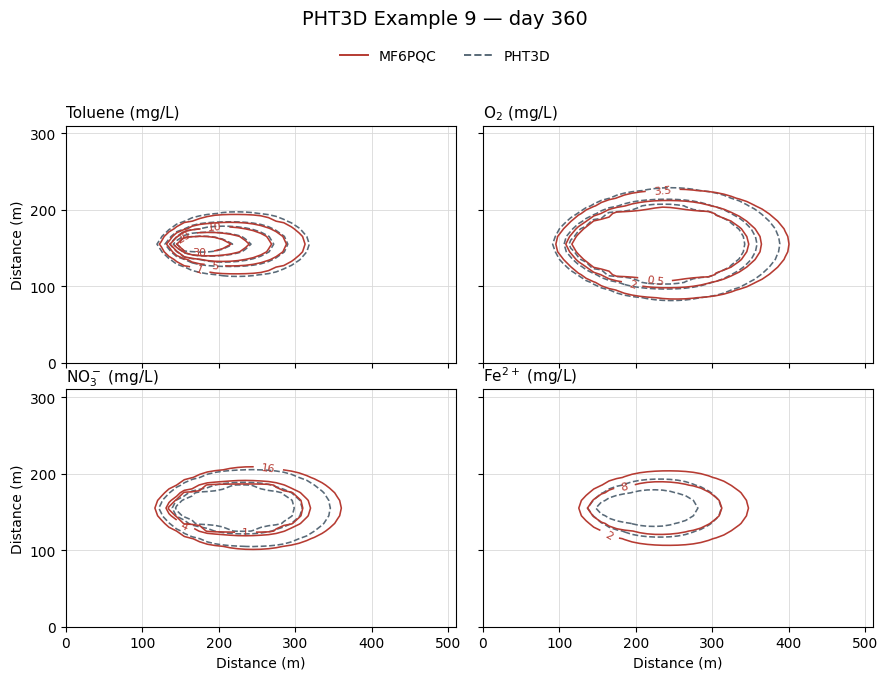

,RMSE,Unit
Variable,,
Toluene,0.213412,mg/L
Oxygen,0.121787,mg/L
Nitrate,0.918999,mg/L
Fe2,2.46434,mg/L


In [1]:
import pandas as pd
from IPython.display import display

comparison_rows = []
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.dont_write_bytecode = True
CASE_DIR = next(
    p
    for root in (Path.cwd(), *Path.cwd().parents)
    for p in (root, root / "examples/ex009_PHT3D_09")
    if p.name == "ex009_PHT3D_09" and (p / "run.py").is_file()
)
sys.path.insert(0, str(CASE_DIR.parent))
from example_utils import load_results, runtime_path, time_indices

CASE_FILE = CASE_DIR / "run.py"
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = runtime_path(CASE_FILE, "output")
SIMULATION_DIR = runtime_path(CASE_FILE, "simulation")
from matplotlib.lines import Line2D

target_time = 360.0
nrow, ncol = (31, 51)
cell_size = 10.0
plot_specs = [
    ("Toluene", 92.14, "Toluene", [1, 5, 10, 20, 30]),
    ("Oxygen", 15.999, "O$_2$", [0.5, 2.0, 3.5]),
    ("Nitrate", 62.005, "NO$_3^-$", [1, 4, 16]),
    ("Fe2", 55.845, "Fe$^{2+}$", [2, 8, 32]),
]
results, headings, result_times = load_results(OUTPUT_DIR)
reference = np.load(INPUT_DIR / "PHT3D_09_results.npy", allow_pickle=False)
required = {"time_days", *(name for name, *_ in plot_specs)}
if not required.issubset(reference.dtype.names or ()):
    raise ValueError(f"Reference data must contain {sorted(required)}")
reference_times = reference["time_days"]
if reference_times.ndim != 1 or not np.isfinite(reference_times).all():
    raise ValueError("Reference times must be a finite one-dimensional array")
if np.any(np.diff(reference_times) <= 0):
    raise ValueError("Reference times must be strictly increasing")
if results.shape[2] != nrow * ncol:
    raise ValueError(f"Expected {nrow * ncol} cells, got {results.shape[2]}")
time_index = int(time_indices(result_times, [target_time])[0])
official_index = int(time_indices(reference_times, [target_time])[0])
mf6pqc_fields, official_fields = ({}, {})
for name, molar_mass, _, _ in plot_specs:
    if name not in headings:
        raise ValueError(f"Missing MF6PQC output: {name}")
    if reference[name].shape != (reference_times.size, nrow, ncol):
        raise ValueError(f"Unexpected reference grid for {name}: {reference[name].shape}")
    modeled = results[time_index, headings.index(name)].reshape(nrow, ncol)
    official = reference[name][official_index]
    if not np.isfinite(modeled).all() or not np.isfinite(official).all():
        raise ValueError(f"Non-finite concentrations for {name} at day {target_time:g}")
    mf6pqc_fields[name] = modeled * 1000 * molar_mass
    official_fields[name] = official * 1000 * molar_mass
x = (np.arange(ncol) + 0.5) * cell_size
y = (np.arange(nrow) + 0.5) * cell_size
X, Y = np.meshgrid(x, y)
model_color, reference_color = ("#B63B32", "#596A78")
fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.8), sharex=True, sharey=True)
for ax, (name, _, title, levels) in zip(axes.flat, plot_specs, strict=True):
    has_contours = False
    for values, color, linestyle in (
        (official_fields[name], reference_color, "--"),
        (mf6pqc_fields[name], model_color, "-"),
    ):
        visible_levels = [level for level in levels if values.min() < level < values.max()]
        if visible_levels:
            contours = ax.contour(
                X,
                Y,
                values,
                levels=visible_levels,
                colors=color,
                linestyles=linestyle,
                linewidths=1.15,
            )
            if linestyle == "-":
                ax.clabel(contours, fmt="%g", fontsize=8, inline=True)
            has_contours = True
    if not has_contours:
        ax.text(0.5, 0.5, "No contours at the listed levels", ha="center", transform=ax.transAxes)
    ax.set_title(f"{title} (mg/L)", loc="left", fontsize=11)
    ax.set(xlim=(0, ncol * cell_size), ylim=(0, nrow * cell_size), aspect="equal")
    ax.set_xticks(np.arange(0, 501, 100))
    ax.set_yticks(np.arange(0, 301, 100))
    ax.grid(True, color="0.85", linewidth=0.6)
    ax.set_axisbelow(True)
for ax in axes[:, 0]:
    ax.set_ylabel("Distance (m)")
for ax in axes[-1]:
    ax.set_xlabel("Distance (m)")
fig.suptitle(f"PHT3D Example 9 — day {target_time:g}", fontsize=14, y=0.98)
fig.legend(
    handles=[
        Line2D([], [], color=model_color, lw=1.4, label="MF6PQC"),
        Line2D([], [], color=reference_color, lw=1.4, ls="--", label="PHT3D"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=2,
    frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()
for name, *_ in plot_specs:
    comparison_rows.append(
        {
            "Variable": name,
            "RMSE": np.sqrt(np.mean((mf6pqc_fields[name] - official_fields[name]) ** 2)),
            "Unit": "mg/L",
        }
    )
comparison = pd.DataFrame(comparison_rows)
comparison = comparison.set_index("Variable")
display(comparison.style.format({"RMSE": "{:.6g}"}).set_uuid("ex009_1"))